# Comparison with decision tree and bagging

In [1]:
# Disable warnings in Anaconda
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 10, 6
%config InlineBackend.figure_format = 'retina'

import seaborn as sns
from sklearn.datasets import make_circles
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                              RandomForestClassifier, RandomForestRegressor)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

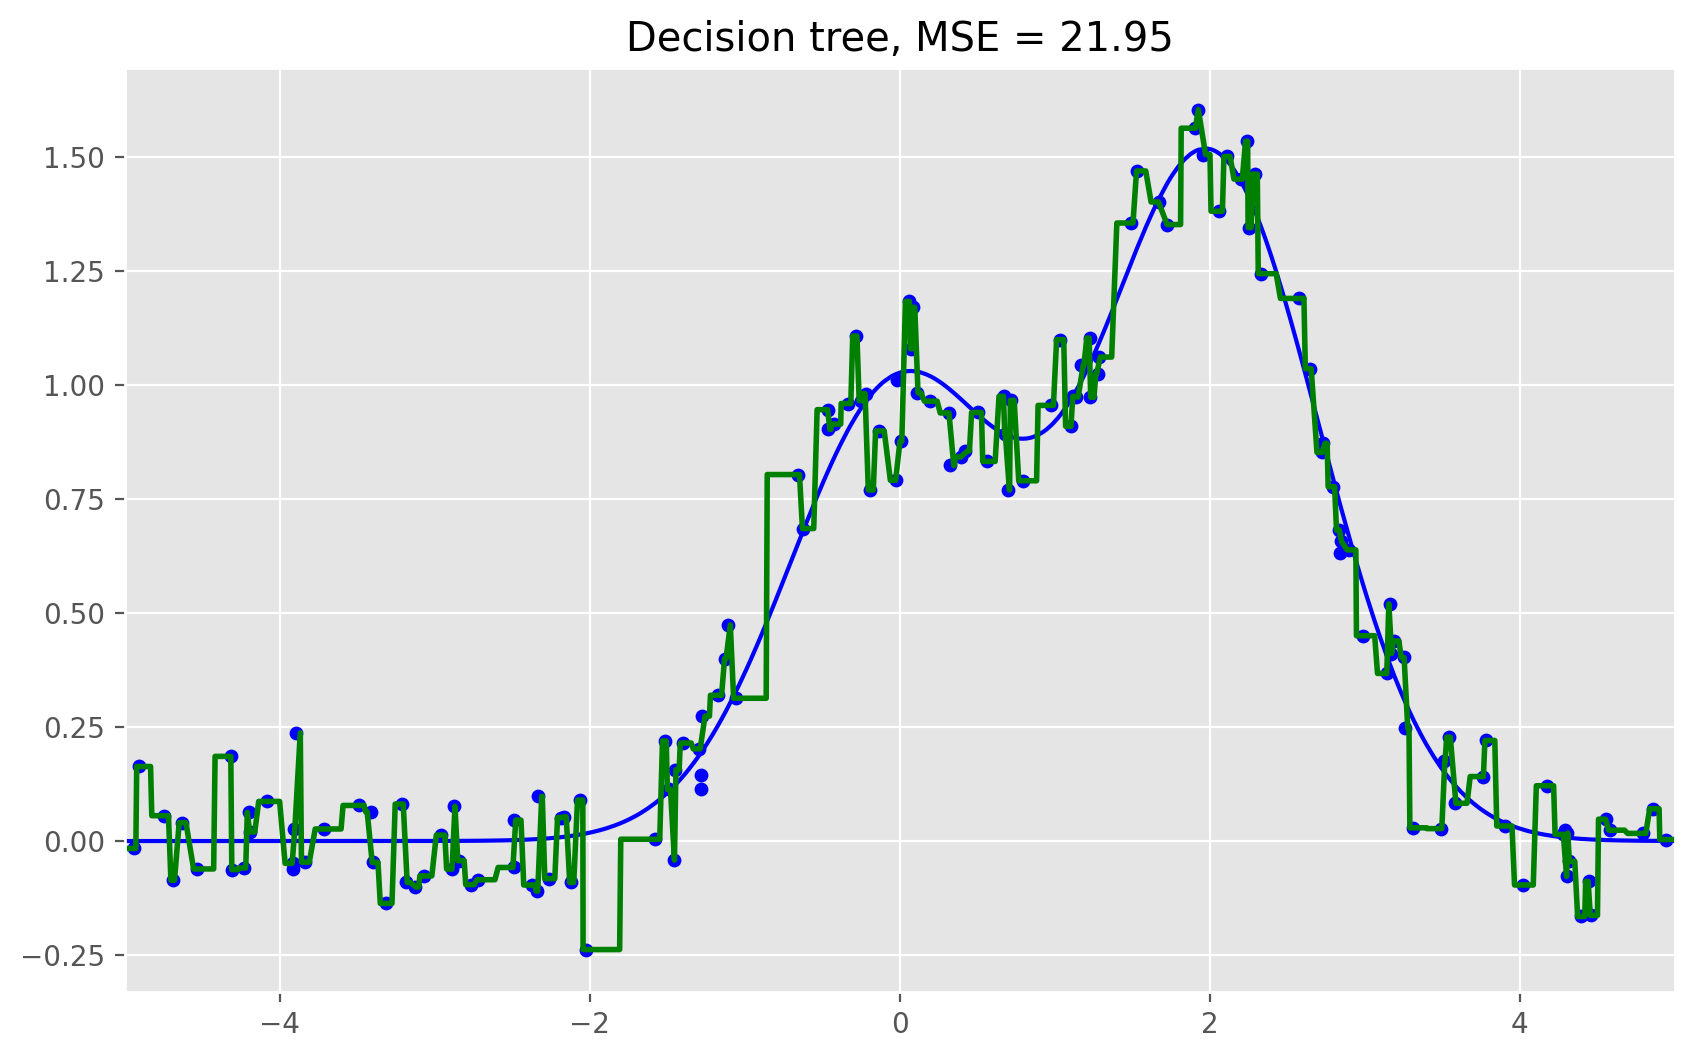

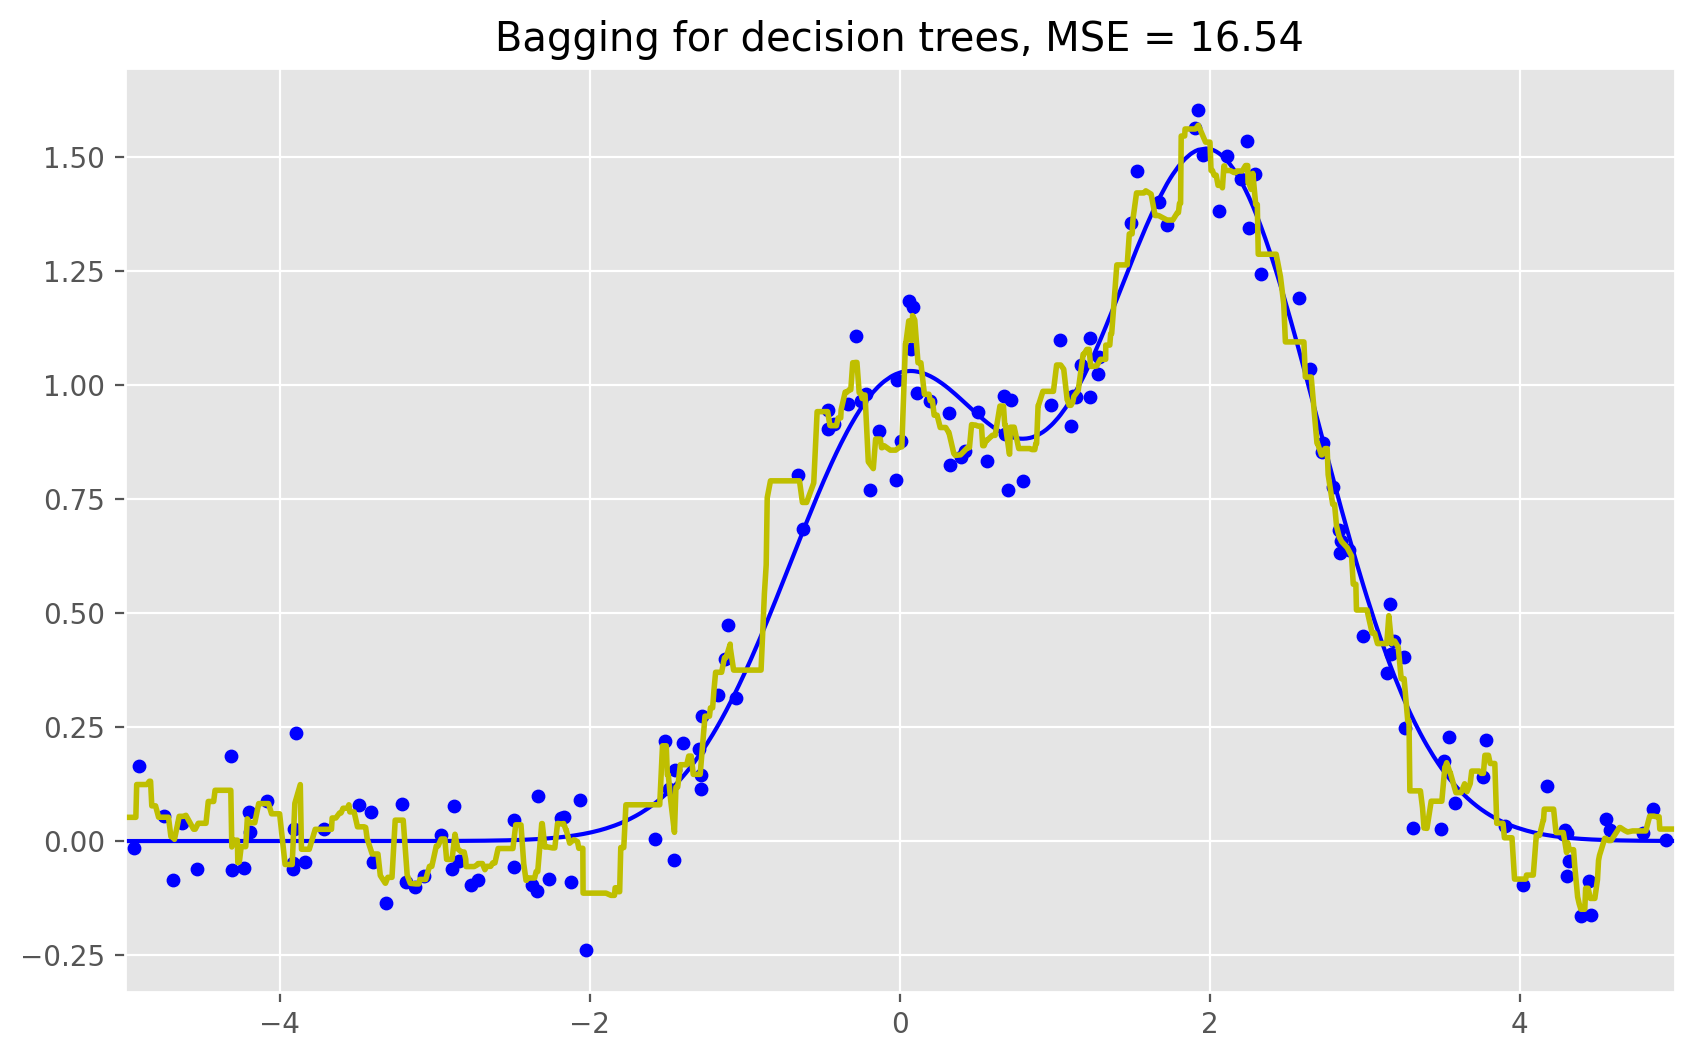

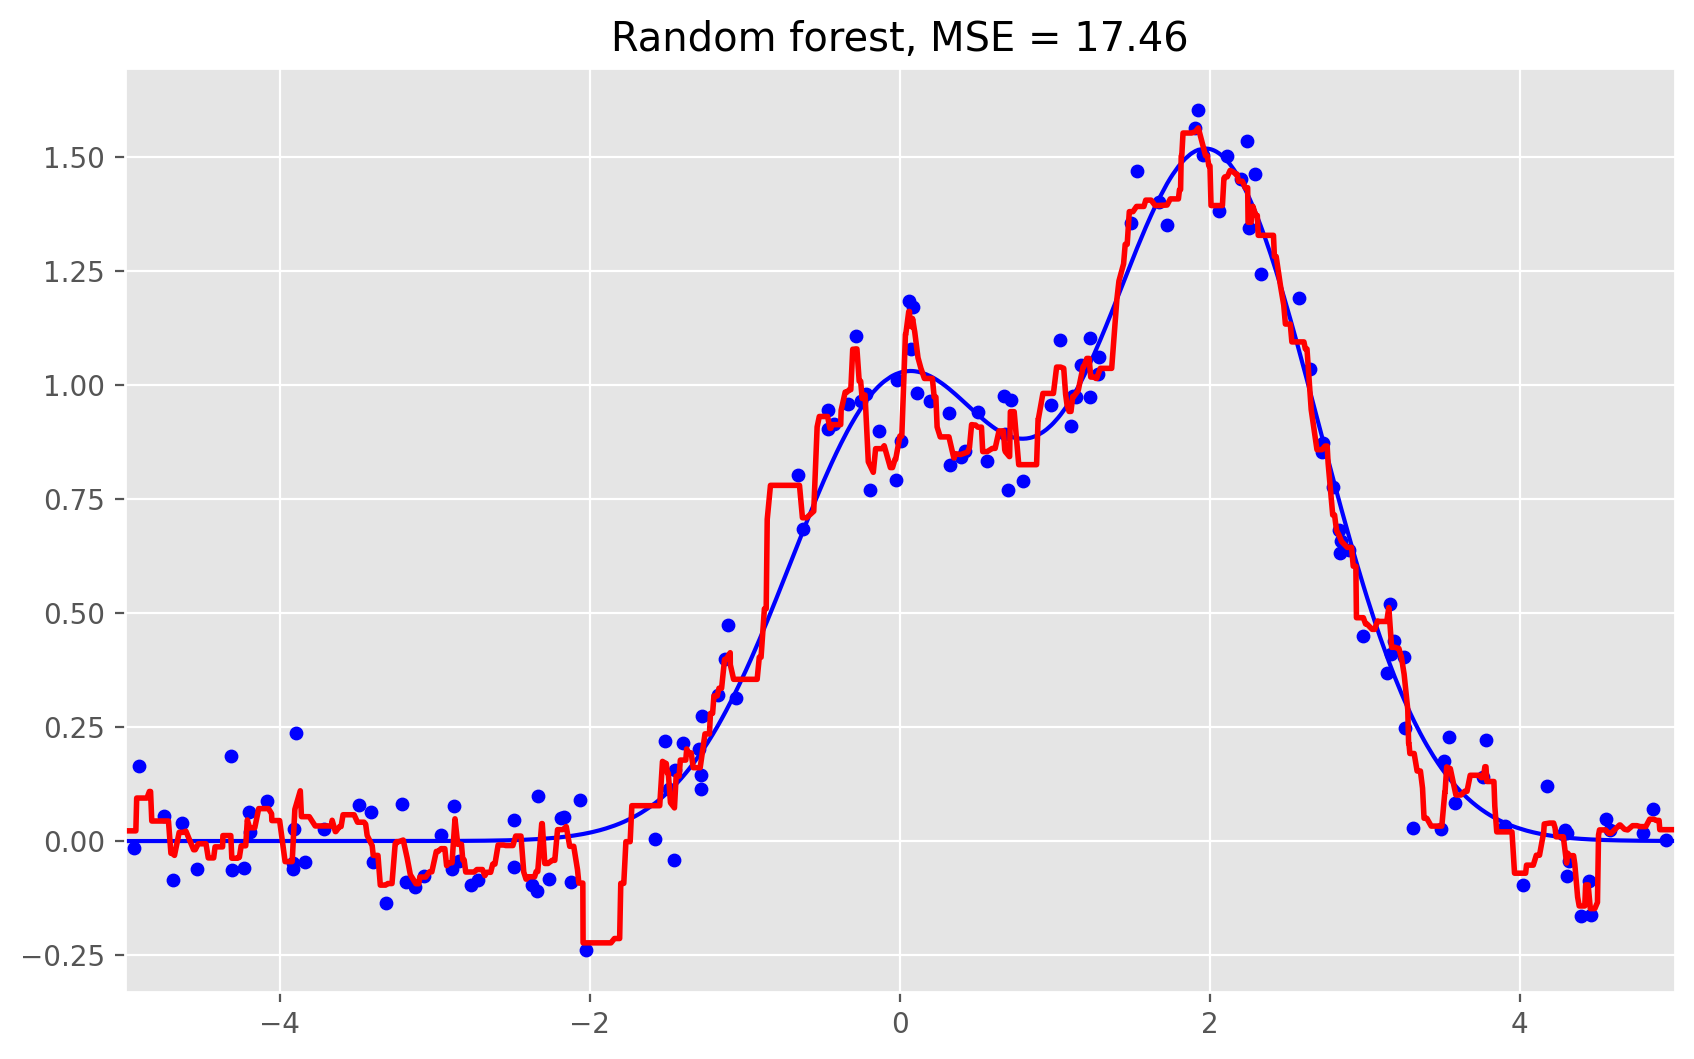

In [2]:
n_train = 150
n_test = 1000
noise = 0.1

# Generate data
# this function is the sum of two gaussian curves, creates two peakes
# function just to visualize the target points
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x-2) ** 2)

def generate(n_samples, noise):
    # creates values between -5 and 5
    X = np.random.rand(n_samples) * 10 - 5 
    X = np.sort(X).ravel()
    # Create target variables similar to f(x), \ in python says the code is not over - it continues in the next line
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    # y = f(X) + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1)) 

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

# One decision tree regressor
dtree = DecisionTreeRegressor().fit(X_train,y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(10,6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f"
          % np.sum((y_test - d_predict) ** 2))
# simple observation - the predicted green line and the scatter blue dots are lying too closely, also not 
# smooth as the blue line. so we may conclude it may due to overfitting

# bagging with a decision tree regressor
bdt = BaggingRegressor(DecisionTreeRegressor()).fit(X_train,y_train)
bdt_predict = bdt.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, bdt_predict, "y", lw=2)
plt.xlim([-5, 5])
plt.title("Bagging for decision trees, MSE = %.2f" % np.sum((y_test - bdt_predict) ** 2))

# Random forest
rf = RandomForestRegressor(n_estimators=10).fit(X_train, y_train)
rf_predict = rf.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "r", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2));


As we can see from our graphs and the MSE values above, a random forest of 10 trees achieves a better result than a single decision tree and is comparable to bagging with 10 trees. The main difference between random forests and bagging is that, in a random forest, the best feature for a split is selected from a random subset of the available features while, in bagging, all features are considered for the next best split.

### Advantages of bagging and random forests in classification problem

In [3]:
X_range = np.linspace(1,10,10)
xx1, xx2 = np.meshgrid(X_range, X_range) # creates grid that can be used as points
y_hat = np.c_[xx1.ravel(), xx2.ravel()]
df = pd.DataFrame({
    "xx1": xx1.ravel(),
    "xx2" : xx2.ravel()
})
df.head(), y_hat[0:5,:]
# np.c_[xx1.ravel(), xx2.ravel()]

(   xx1  xx2
 0  1.0  1.0
 1  2.0  1.0
 2  3.0  1.0
 3  4.0  1.0
 4  5.0  1.0,
 array([[1., 1.],
        [2., 1.],
        [3., 1.],
        [4., 1.],
        [5., 1.]]))

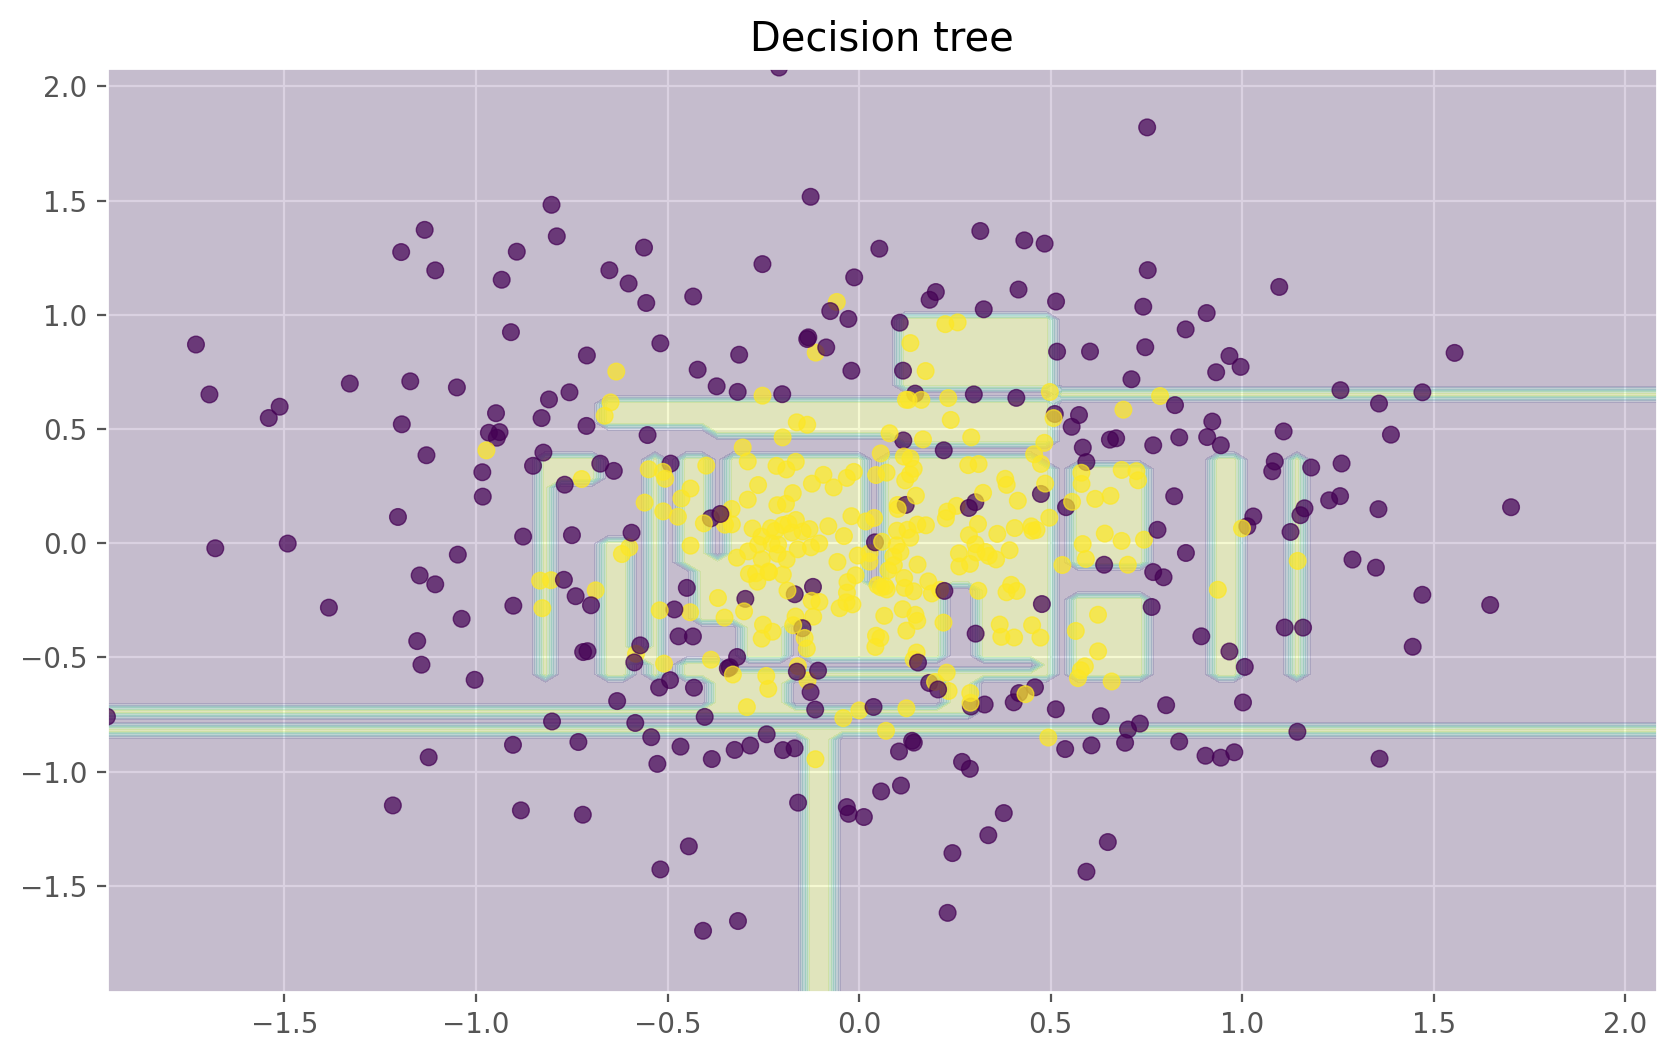

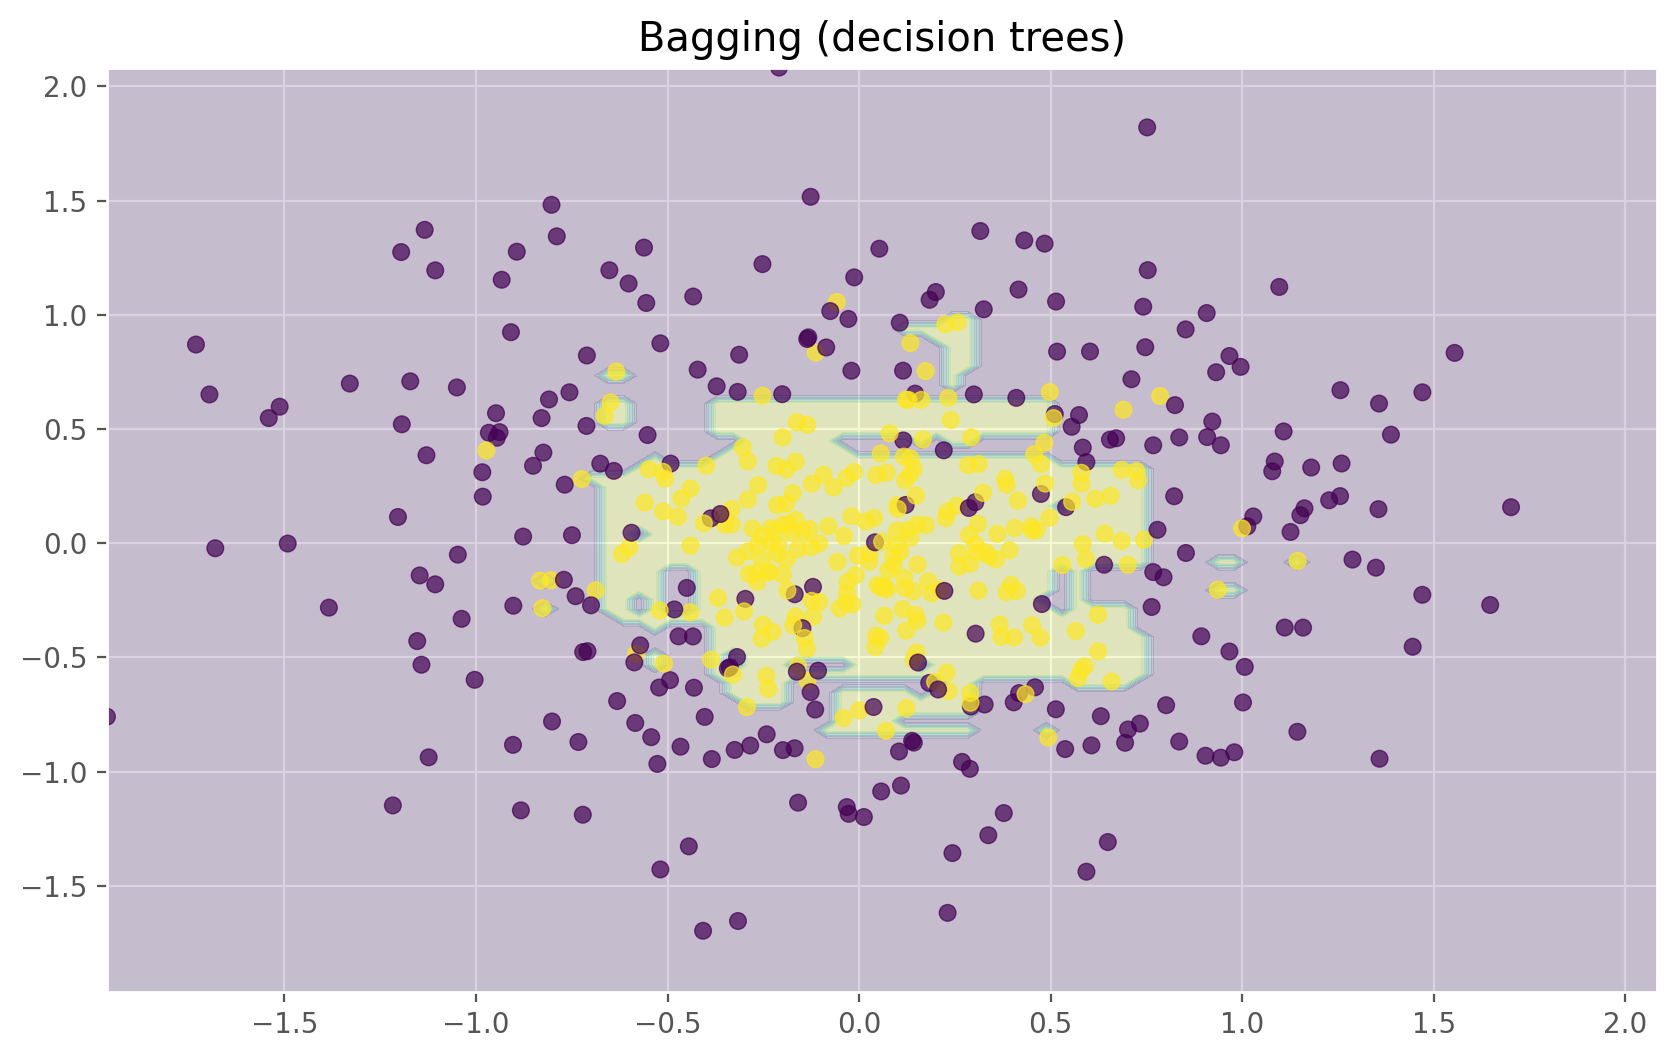

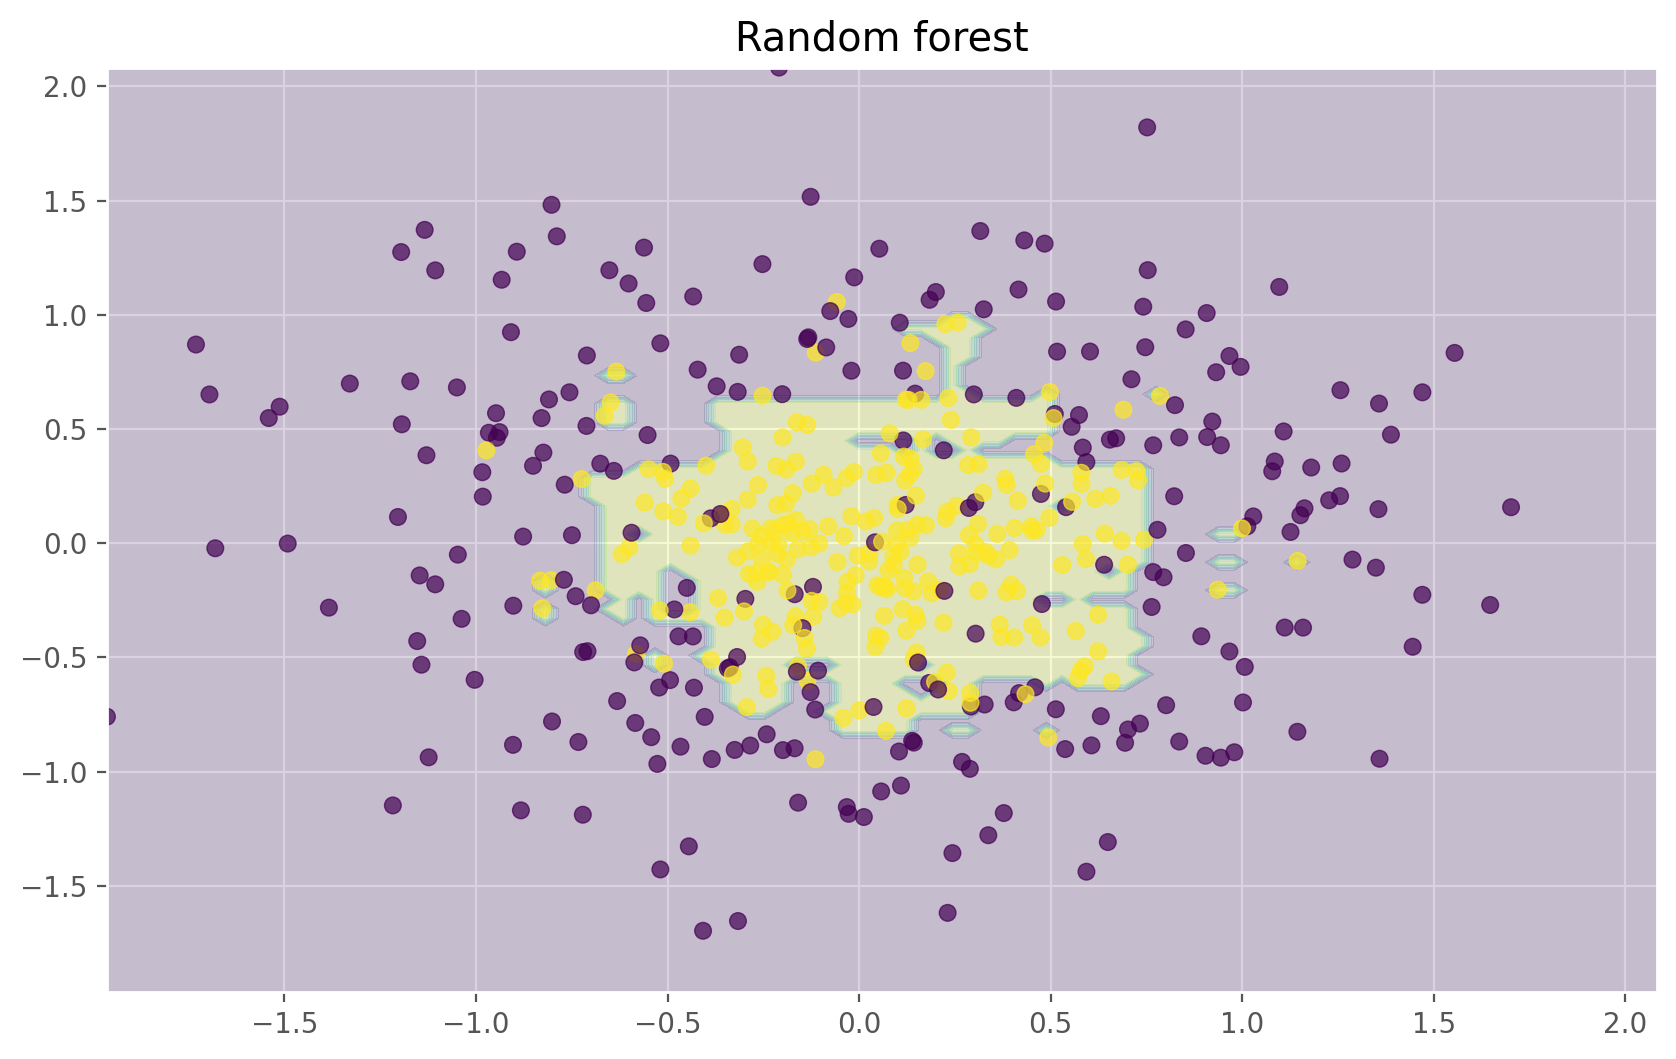

In [4]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train_circles, X_test_circles, y_train_circles, y_test_circles = \
    train_test_split(X, y, test_size=0.2)

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_circles, y_train_circles)

X_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(X_range,X_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()

b_dtree = BaggingClassifier(DecisionTreeClassifier(),
                            n_estimators=300, random_state=42)
b_dtree.fit(X_train_circles, y_train_circles)

x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = b_dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Bagging (decision trees)")
plt.show()

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_circles, y_train_circles)

x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

The figures above show that the decision boundary of the decision tree is quite jagged and has a lot of acute angles that suggest overfitting and a weak ability to generalize. We would have trouble making reliable predictions on new test data. In contrast, the bagging algorithm has a rather smooth boundary and has no obvious signs of overfitting.

## Parameters

Here are simplified notes that you can use for revision.

---

# Random Forest Parameters (Simple Notes)

A **Random Forest** is a collection of decision trees. These parameters control **how many trees are created** and **how each tree grows**.

---

## 1. `n_estimators`

**Meaning:** Number of decision trees in the forest.

```python
RandomForestClassifier(n_estimators=100)
```

* More trees → Usually better accuracy.
* Too many trees → Slower training and prediction.

**Default:** `100` (older versions used `10`)

**Remember:** **More trees = More votes = Better stability.**

---

## 2. `criterion`

**Meaning:** Decides how the tree chooses the best split.

### Classification

* `"gini"` → Uses Gini Impurity
* `"entropy"` → Uses Information Gain

```python
criterion="gini"
```

### Regression

* `"squared_error"` (formerly `"mse"`) → Uses Mean Squared Error
* `"absolute_error"` (formerly `"mae"`) → Uses Mean Absolute Error

**Remember:**

* Classification → Gini / Entropy
* Regression → Squared Error / Absolute Error

---

## 3. `max_features`

**Meaning:** Number of features considered when searching for the best split.

Example:

Suppose your dataset has

```text
10 features
```

If

```python
max_features=3
```

the tree randomly picks **3 features** and finds the best split only among those.

Possible values:

* Integer

```python
max_features=5
```

* Fraction

```python
max_features=0.5
```

(50% of features)

* `"sqrt"`

Uses

[
\sqrt{\text{number of features}}
]

* `"log2"`

Uses

[
\log_2(\text{number of features})
]

**Why?**

Randomly selecting features makes different trees less similar, which improves the forest.

---

## 4. `max_depth`

**Meaning:** Maximum depth of each tree.

```python
max_depth=5
```

Example:

```text
Root
 |
 |--Depth 1
      |
      |--Depth 2
            |
            |--Depth 3
```

Small depth

* Simpler tree
* Faster
* Less overfitting

Large depth

* Complex tree
* Can overfit

---

## 5. `min_samples_split`

**Meaning:** Minimum number of samples needed before a node can split.

Example

```text
Node has

8 samples
```

If

```python
min_samples_split=10
```

No split occurs.

If

```python
min_samples_split=2
```

Split is allowed.

Higher value → Simpler tree.

---

## 6. `min_samples_leaf`

**Meaning:** Minimum number of samples allowed in each leaf.

Example

Bad split

```text
Left leaf : 1 sample

Right leaf : 99 samples
```

If

```python
min_samples_leaf=5
```

This split is not allowed.

Higher value reduces overfitting.

---

## 7. `min_weight_fraction_leaf`

Same idea as `min_samples_leaf`, but uses **sample weights** instead of the number of samples.

Most beginners don't use this.

Default:

```python
0
```

---

## 8. `max_leaf_nodes`

Limits the total number of leaf nodes.

Example

```python
max_leaf_nodes=20
```

The tree stops growing after creating 20 leaves.

Useful for controlling model complexity.

---

## 9. `bootstrap`

```python
bootstrap=True
```

Should each tree be trained on a random sample of the training data?

* `True` ✔ (normal Random Forest)
* `False` → Every tree uses the entire dataset.

**Remember:**

Bootstrap = Random sampling **with replacement**.

---

## 10. `oob_score`

Out-of-Bag Score

```python
oob_score=True
```

Since each tree is trained on only part of the data, some samples are left out.

Those unused samples are called

**Out-of-Bag samples**

They can be used to estimate model performance without needing a separate validation set.

Usually left as

```python
False
```

unless you specifically want an OOB estimate.

---

## 11. `n_jobs`

Controls CPU usage.

```python
n_jobs=1
```

Uses one CPU core.

```python
n_jobs=-1
```

Uses **all CPU cores**.

Faster training.

---

## 12. `random_state`

Controls randomness.

```python
random_state=42
```

Every run produces the same forest.

Useful for reproducible results.

---

## 13. `verbose`

Controls how much information is printed while training.

```python
verbose=0
```

No messages.

```python
verbose=1
```

Some progress messages.

Useful only for debugging.

---

## 14. `warm_start`

```python
warm_start=True
```

Instead of creating a brand-new forest,

keep the existing trees and **add more**.

Example

```python
rf = RandomForestClassifier(
    n_estimators=100,
    warm_start=True
)

rf.fit(X, y)

rf.set_params(n_estimators=150)

rf.fit(X, y)
```

Now the forest has

```text
150 trees
```

instead of rebuilding from scratch.

---

# Classification-only Parameter

## `class_weight`

Useful when classes are imbalanced.

Example

```text
990 Cats

10 Dogs
```

Without weights

The model mostly predicts

```text
Cat
```

because cats dominate.

Using

```python
class_weight="balanced"
```

gives more importance to the minority class.

Possible values

```python
None
```

No weighting.

```python
"balanced"
```

Automatic balancing.

```python
{0:1, 1:5}
```

Manual weights.

---

# Quick Revision Table

| Parameter                  | Simple Meaning                                                          |
| -------------------------- | ----------------------------------------------------------------------- |
| `n_estimators`             | Number of trees                                                         |
| `criterion`                | How the best split is chosen                                            |
| `max_features`             | Number of features checked at each split                                |
| `max_depth`                | Maximum depth of a tree                                                 |
| `min_samples_split`        | Minimum samples needed to split a node                                  |
| `min_samples_leaf`         | Minimum samples allowed in a leaf                                       |
| `min_weight_fraction_leaf` | Minimum weighted fraction required in a leaf (used with sample weights) |
| `max_leaf_nodes`           | Maximum number of leaf nodes                                            |
| `bootstrap`                | Use random sampling with replacement for each tree                      |
| `oob_score`                | Evaluate using out-of-bag samples                                       |
| `n_jobs`                   | Number of CPU cores to use (`-1` = all cores)                           |
| `random_state`             | Seed for reproducible results                                           |
| `verbose`                  | Controls training output messages                                       |
| `warm_start`               | Add more trees to an existing forest instead of rebuilding it           |
| `class_weight`             | Give more importance to certain classes (classification only)           |

## Easy way to remember the most important ones

In practice, the parameters you'll tune most often are:

* **`n_estimators`** → How many trees?
* **`max_depth`** → How deep can each tree grow?
* **`max_features`** → How many features can a tree consider at each split?
* **`min_samples_split`** → When is a node allowed to split?
* **`min_samples_leaf`** → How small can a leaf become?
* **`bootstrap`** → Should each tree use a random bootstrap sample?
* **`random_state`** → Make results reproducible.
* **`class_weight`** → Handle imbalanced classes (classification only).

These eight parameters account for the majority of Random Forest tuning in real-world machine learning projects.


## Practice with Random Forest in real problem

In this example we will look at predicting customer churn. This is a classification problem, so we will use accuracy for model evaluation.

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
df = pd.read_csv(DATA_PATH + "telecom_churn.csv")

# Choose numeric features
cols = []
for i in df.columns:
    if (df[i].dtype == "float64") or (df[i].dtype == 'int64'):
        cols.append(i)

# Divide the dataset into input and target
X, y = df[cols].copy(), np.asarray(df["Churn"],dtype='int8')

# Initialize a stratified split of our dataset for the validation process
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the classifier with the default parameters
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)

# train it on the training set
results = cross_val_score(rfc, X, y, cv=skf)

# Evaluate the accuract in the test set
print("CV accuracy score: {:.2f}%".format(results.mean() * 100))

CV accuracy score: 92.50%


We have accuracy equal to 91.18%. Now, let’s try to improve this result, and take a look at the behavior of the learning curves when we change the basic parameters.

In [10]:
# Initilize the validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create lists to save the values of accuracy of training and test sets
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
tree_grid = [5,10,15,20,30,50,75,100]

for ntrees in tree_grid:
    rfc = RandomForestClassifier(n_estimators=ntrees, random_state=42, n_jobs=-1)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best CV accuracy is {:.2f}% with {} trees".format(max(test_acc.mean(axis=1))*100,
                                                        tree_grid[np.argmax(test_acc.mean(axis=1))]))

Best CV accuracy is 92.50% with 100 trees
